In [1]:
import os
import zipfile
import pandas as pd

In [2]:
df = pd.read_csv('/content/churn_data_clean.csv')
df.head()

,Unnamed: 0,customer_id,age,gender,region,contract_type,tenure_months,internet_service,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,payment_method,satisfaction_score,churn,total_spend,engagement_score,payment_behavior
0,0,1,56,Female,Asia,Month-to-Month,42,5G,49.49,244.86,4.92,2,1,Digital Wallet,5,0,2078.58,124.890,1
1,1,2,69,Male,Europe,Two Year,23,DSL,92.74,211.98,4.04,4,0,Debit Card,3,0,2133.02,108.010,0
2,2,3,46,Female,South America,Month-to-Month,64,5G,26.95,179.35,6.92,3,0,Bank Transfer,7,0,1724.80,93.135,0
3,3,4,32,Female,North America,Month-to-Month,38,Fiber Optic,69.06,5.00,4.19,5,0,Credit Card,9,1,2624.28,4.595,0
4,4,5,60,Male,Asia,One Year,57,Fiber Optic,64.55,193.71,4.09,2,1,Debit Card,4,0,3679.35,98.900,1


In [3]:
df_1 = df.copy()

In [4]:
df.isnull().sum()

,0
Unnamed: 0,0
customer_id,0
age,0
gender,0
region,0
contract_type,0
tenure_months,0
internet_service,0
monthly_charges,0
data_usage_gb,0


In [5]:
df['internet_service'].value_counts()

,count
internet_service,
Fiber Optic,112918
DSL,74795
5G,49719
no internet service,12568


In [6]:
df['region'].value_counts()

,count
region,
North America,87447
Europe,62737
Asia,50015
Africa,24940
South America,24861


In [7]:
df['contract_type'].value_counts()

,count
contract_type,
Month-to-Month,149548
One Year,62697
Two Year,37755


In [8]:
df['late_payments'].value_counts()

,count
late_payments,
1,92037
0,91947
2,45686
3,15421
4,3970
5,798
6,116
7,22
8,3


In [9]:
df['payment_method'].value_counts()

,count
payment_method,
Bank Transfer,62808
Debit Card,62630
Digital Wallet,62431
Credit Card,62131


In [10]:
df.shape

(250000, 19)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 250000 non-null  int64  
 1   customer_id                250000 non-null  int64  
 2   age                        250000 non-null  int64  
 3   gender                     250000 non-null  object 
 4   region                     250000 non-null  object 
 5   contract_type              250000 non-null  object 
 6   tenure_months              250000 non-null  int64  
 7   internet_service           250000 non-null  object 
 8   monthly_charges            250000 non-null  float64
 9   data_usage_gb              250000 non-null  float64
 10  avg_call_duration_minutes  250000 non-null  float64
 11  support_calls              250000 non-null  int64  
 12  late_payments              250000 non-null  int64  
 13  payment_method             25

In [12]:

df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Unnamed: 0,customer_id,age,tenure_months,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,satisfaction_score,churn,total_spend,engagement_score,payment_behavior
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,124999.500000,125000.500000,48.477260,35.994648,70.139377,120.777795,6.000264,1.999264,1.001664,5.502472,0.305952,2523.902574,63.389030,0.632212
std,72168.927986,72168.927986,17.890369,20.484175,24.488268,58.535946,1.984779,1.414273,1.003303,2.869427,0.460810,1759.352722,29.286993,0.482204
min,0.000000,1.000000,18.000000,1.000000,20.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,3.000000,0.000000
25%,62499.750000,62500.750000,33.000000,18.000000,53.100000,79.690000,4.650000,1.000000,0.000000,3.000000,0.000000,1091.730000,42.830000,0.000000
50%,124999.500000,125000.500000,48.000000,36.000000,69.910000,120.140000,5.990000,2.000000,1.000000,6.000000,0.000000,2230.150000,63.040000,1.000000
75%,187499.250000,187500.250000,64.000000,54.000000,86.840000,160.600000,7.350000,3.000000,2.000000,8.000000,1.000000,3666.255000,83.315000,1.000000
max,249999.000000,250000.000000,79.000000,71.000000,150.000000,385.560000,14.680000,10.000000,8.000000,10.000000,1.000000,10650.000000,195.090000,1.000000


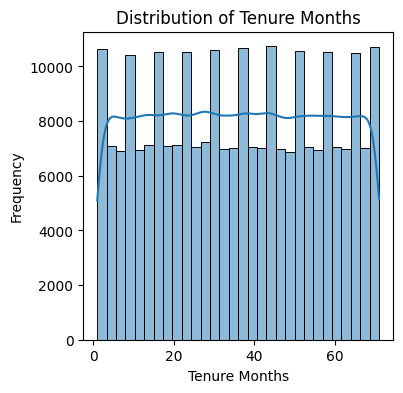

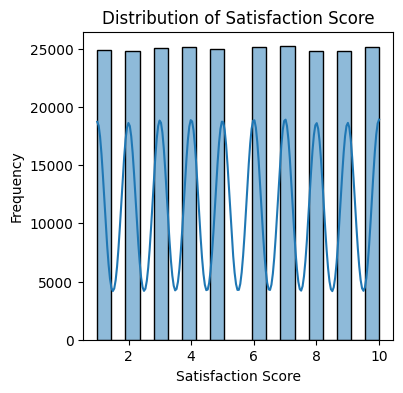

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
sns.histplot(df['tenure_months'], bins=30, kde=True)
plt.title('Distribution of Tenure Months')
plt.xlabel('Tenure Months')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(4,4))
sns.histplot(df['satisfaction_score'], bins=20, kde=True)
plt.title('Distribution of Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')
plt.show()

In [15]:
df.head()

,Unnamed: 0,customer_id,age,gender,region,contract_type,tenure_months,internet_service,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,payment_method,satisfaction_score,churn,total_spend,engagement_score,payment_behavior
0,0,1,56,Female,Asia,Month-to-Month,42,5G,49.49,244.86,4.92,2,1,Digital Wallet,5,0,2078.58,124.890,1
1,1,2,69,Male,Europe,Two Year,23,DSL,92.74,211.98,4.04,4,0,Debit Card,3,0,2133.02,108.010,0
2,2,3,46,Female,South America,Month-to-Month,64,5G,26.95,179.35,6.92,3,0,Bank Transfer,7,0,1724.80,93.135,0
3,3,4,32,Female,North America,Month-to-Month,38,Fiber Optic,69.06,5.00,4.19,5,0,Credit Card,9,1,2624.28,4.595,0
4,4,5,60,Male,Asia,One Year,57,Fiber Optic,64.55,193.71,4.09,2,1,Debit Card,4,0,3679.35,98.900,1


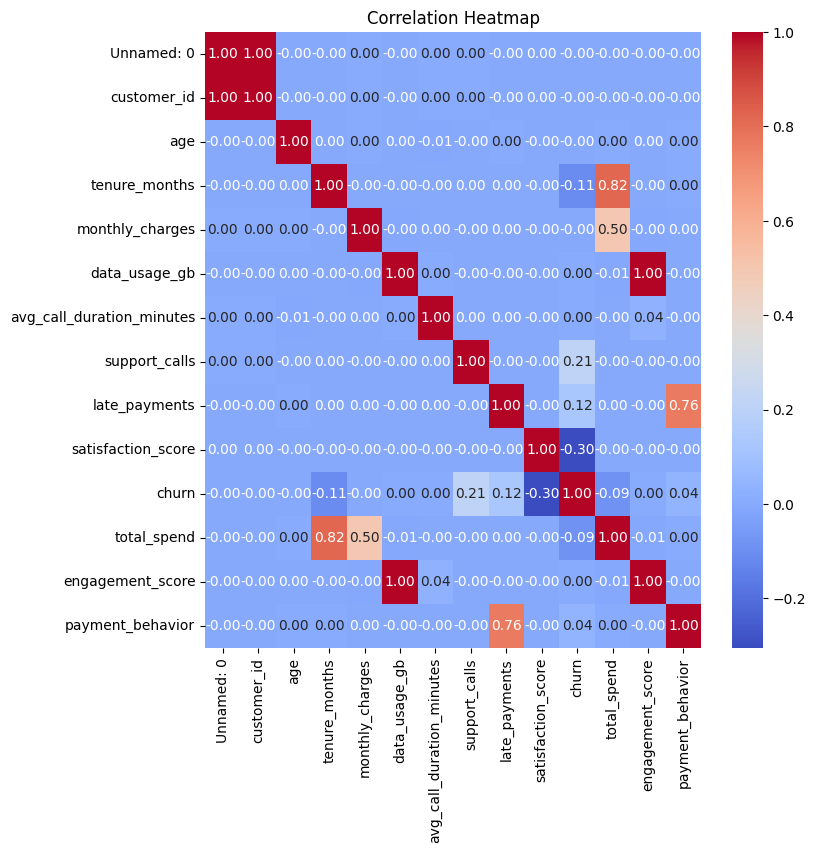

In [16]:
# correlation heat map
# Selecting numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()


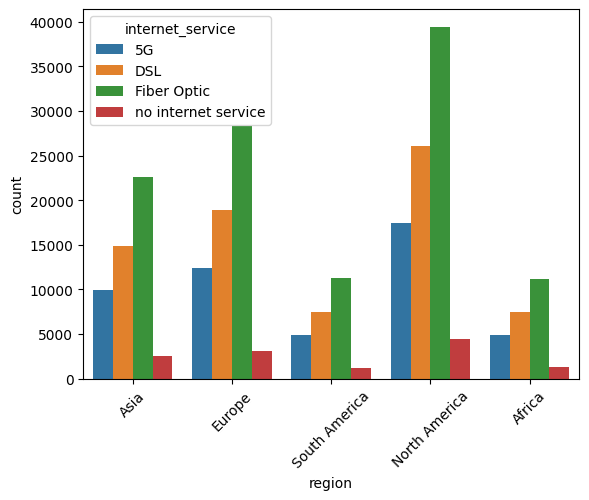

In [17]:
# region effect no int useage countplot
sns.countplot(x='region', hue='internet_service', data=df)
plt.xticks(rotation=45)
plt.show()

In [18]:
df.isnull().sum()

,0
Unnamed: 0,0
customer_id,0
age,0
gender,0
region,0
contract_type,0
tenure_months,0
internet_service,0
monthly_charges,0
data_usage_gb,0


In [19]:
df.head()

,Unnamed: 0,customer_id,age,gender,region,contract_type,tenure_months,internet_service,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,payment_method,satisfaction_score,churn,total_spend,engagement_score,payment_behavior
0,0,1,56,Female,Asia,Month-to-Month,42,5G,49.49,244.86,4.92,2,1,Digital Wallet,5,0,2078.58,124.890,1
1,1,2,69,Male,Europe,Two Year,23,DSL,92.74,211.98,4.04,4,0,Debit Card,3,0,2133.02,108.010,0
2,2,3,46,Female,South America,Month-to-Month,64,5G,26.95,179.35,6.92,3,0,Bank Transfer,7,0,1724.80,93.135,0
3,3,4,32,Female,North America,Month-to-Month,38,Fiber Optic,69.06,5.00,4.19,5,0,Credit Card,9,1,2624.28,4.595,0
4,4,5,60,Male,Asia,One Year,57,Fiber Optic,64.55,193.71,4.09,2,1,Debit Card,4,0,3679.35,98.900,1


In [20]:
df['gender'] = df['gender'].map({
    'Male':1,
    'Female':0
})

In [21]:
df.head()

,Unnamed: 0,customer_id,age,gender,region,contract_type,tenure_months,internet_service,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,payment_method,satisfaction_score,churn,total_spend,engagement_score,payment_behavior
0,0,1,56,0,Asia,Month-to-Month,42,5G,49.49,244.86,4.92,2,1,Digital Wallet,5,0,2078.58,124.890,1
1,1,2,69,1,Europe,Two Year,23,DSL,92.74,211.98,4.04,4,0,Debit Card,3,0,2133.02,108.010,0
2,2,3,46,0,South America,Month-to-Month,64,5G,26.95,179.35,6.92,3,0,Bank Transfer,7,0,1724.80,93.135,0
3,3,4,32,0,North America,Month-to-Month,38,Fiber Optic,69.06,5.00,4.19,5,0,Credit Card,9,1,2624.28,4.595,0
4,4,5,60,1,Asia,One Year,57,Fiber Optic,64.55,193.71,4.09,2,1,Debit Card,4,0,3679.35,98.900,1


In [22]:
df['region']=df['region'].map({
    'Asia':0,
    'Europe':1,
    'South America':2,
    'North America':3,
    'Africa':4
})

In [23]:
df.head()

,Unnamed: 0,customer_id,age,gender,region,contract_type,tenure_months,internet_service,monthly_charges,data_usage_gb,avg_call_duration_minutes,support_calls,late_payments,payment_method,satisfaction_score,churn,total_spend,engagement_score,payment_behavior
0,0,1,56,0,0,Month-to-Month,42,5G,49.49,244.86,4.92,2,1,Digital Wallet,5,0,2078.58,124.890,1
1,1,2,69,1,1,Two Year,23,DSL,92.74,211.98,4.04,4,0,Debit Card,3,0,2133.02,108.010,0
2,2,3,46,0,2,Month-to-Month,64,5G,26.95,179.35,6.92,3,0,Bank Transfer,7,0,1724.80,93.135,0
3,3,4,32,0,3,Month-to-Month,38,Fiber Optic,69.06,5.00,4.19,5,0,Credit Card,9,1,2624.28,4.595,0
4,4,5,60,1,0,One Year,57,Fiber Optic,64.55,193.71,4.09,2,1,Debit Card,4,0,3679.35,98.900,1


In [24]:
df['contract_type']= df['contract_type'].map({
    'Month-to-Month':0,
    'One Year':1,
    'Two Year':2
})

In [25]:
df['internet_service']= df['internet_service'].map({
    'Fiber Optic':0,
    'DSL':1,
    '5G':2,
    'no internet service':3
})

In [26]:
df['payment_method']= df['payment_method'].map({
    'Bank Transfer':0,
    'Debit Card':1,
    'Digital Wallet':2,
    'Credit Card':3
})

In [27]:
x = df.drop('churn', axis = 1)
y= df['churn']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify = y, random_state = 2)

In [30]:
print(x.shape, x_train.shape, x_test.shape)

(250000, 18) (200000, 18) (50000, 18)


In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [33]:
x_train_standard = scaler.fit_transform(x_train)
x_test_standard = scaler.transform(x_test)

In [34]:
!pip install xgboost

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [36]:
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "Random Forest": RandomForestClassifier(),
#     "Gradient Boosting": GradientBoostingClassifier()}

In [37]:
models = [LogisticRegression(max_iter = 1000),RandomForestClassifier(n_jobs=-1),XGBClassifier(tree_method='hist')]

In [38]:
def compair_model():
  for model in models:
    model.fit(x_train_standard, y_train)
    test_data_pred = model.predict(x_test_standard)
    accuracy = accuracy_score(y_test,test_data_pred)
    print(f'Accuracy score of {model} is {accuracy:.4f}')

In [39]:
compair_model()

Accuracy score of LogisticRegression(max_iter=1000) is 0.8308
Accuracy score of RandomForestClassifier(n_jobs=-1) is 0.8865
Accuracy score of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) is 0.8867


In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [41]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
raw_ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [42]:
param_dist = {
    'n_estimators': randint(100, 400),
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'scale_pos_weight': [1, raw_ratio, raw_ratio * 1.5]
}


rgcv = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42
)

rgcv.fit(x_train_standard, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:40:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e6a0fff32f0>,
                                        'scale_pos_weight': [1,
                                                             np.float64(2.2685079261317207),
                                                             np.float64(3.4027618891975813)],
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e6a0fff33e0>},
                   random_state=42, scoring='average_precision')

In [43]:
# Predict probabilities for the entire encoded dataset
# [:, 1] extracts the probability of the positive class (Class 1 = Churn)
probabilities = rgcv.predict_proba(x_train_standard)[:, 1]

In [44]:
import numpy as np
import pandas as pd

# 1. Stack the standardized numpy arrays together
x_full_standard = np.vstack([x_train_standard, x_test_standard])

# 2. Reconstruct the original index order using your lowercase splits
# (This ensures the row order matches the stacked array perfectly)
all_indices = np.concatenate([x_train.index, x_test.index])

# 3. Predict the churn probabilities
all_probabilities = rgcv.predict_proba(x_full_standard)[:, 1]

# 4. Map the probabilities to their original indices using a Series
prob_mapping = pd.Series(all_probabilities, index=all_indices)

# 5. Create a clean copy of your original dataframe 'df'
clean_dataset_prob = df.copy()

# 6. Safely align and assign the probabilities back to the rows using the index map
clean_dataset_prob['Churn_Probability'] = clean_dataset_prob.index.map(prob_mapping)
clean_dataset_prob['Churn_Probability_pct'] = (clean_dataset_prob['Churn_Probability'] * 100).round(2).astype(str) + '%'

# 7. Print to check your new columns
print(clean_dataset_prob[['Churn_Probability', 'Churn_Probability_pct']].head())

   Churn_Probability Churn_Probability_pct
0           0.115643                11.56%
1           0.372340                37.23%
2           0.131149                13.11%
3           0.897984                 89.8%
4           0.008412                 0.84%


In [45]:
clean_dataset_prob.to_csv(r"C:\Users\Administrator\Desktop\customer_churn_project\data\final_dataset.csv")

In [46]:
import joblib
joblib.dump(rgcv, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']